In [1]:
from torch.utils.data import TensorDataset, DataLoader
from pathlib import Path
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

Training trajectories shape: torch.Size([1000, 100, 24])
Training controls shape: torch.Size([1000, 99, 2])
Testing trajectories shape: torch.Size([215, 100, 24])
Testing controls shape: torch.Size([215, 99, 2])


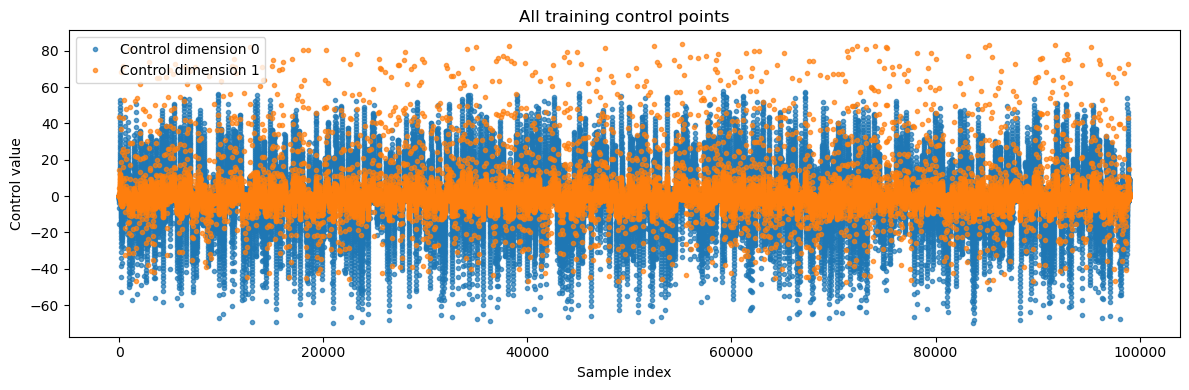

In [2]:
import load

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
trajectories_tensor_train = load.trajectories_tensor_train
controls_tensor_train = load.controls_tensor_train
trajectories_tensor_test = load.trajectories_tensor_test
controls_tensor_test = load.controls_tensor_test

In [5]:
batch_size = 32

torch_dataset_train = TensorDataset(trajectories_tensor_train, controls_tensor_train)
torch_dataset_test = TensorDataset(trajectories_tensor_test, controls_tensor_test)

train_dataloader = DataLoader(torch_dataset_train,
                              batch_size=batch_size,
                              shuffle=True)

test_dataloader = DataLoader(torch_dataset_test,
                             batch_size=batch_size,
                             shuffle=False)

In [6]:
trajectory, controls = next(iter(train_dataloader))
#print(controls.shape,controls[0,-1,0])
#plt.plot(controls[0,:,1].numpy())
print("batch trajectory shape:", trajectory.shape)
print("batch controls shape:", controls.shape)
print("one trajectory shape:", trajectory[0].shape)
print("one control shape:", controls[0].shape)
print("one state shape:", trajectory[0, 0].shape)

batch trajectory shape: torch.Size([32, 100, 24])
batch controls shape: torch.Size([32, 99, 2])
one trajectory shape: torch.Size([100, 24])
one control shape: torch.Size([99, 2])
one state shape: torch.Size([24])


In [7]:
feature_dim = 24      # dimension of the marker/state space
hidden_layers = 5     # number of hidden layers
latent_dim = 8        # Koopman latent dimension

In [8]:
class Encoder(nn.Module):
    def __init__(self, layer_dims: list[int]):
        super().__init__()

        layers = []
        for in_dim, out_dim in zip(layer_dims[:-2], layer_dims[1:-1]):
            layers.append(nn.Linear(in_dim, out_dim))
            layers.append(nn.ELU())
        layers.append(nn.Linear(layer_dims[-2], layer_dims[-1]))

        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

In [9]:
class Decoder(nn.Module):
    def __init__(self, layer_dims: list[int]):
        super().__init__()

        reversed_dims = list(reversed(layer_dims))

        layers = []
        for in_dim, out_dim in zip(reversed_dims[:-2], reversed_dims[1:-1]):
            layers.append(nn.Linear(in_dim, out_dim))
            layers.append(nn.ELU())

        layers.append(nn.Linear(reversed_dims[-2], reversed_dims[-1]))
        self.network = nn.Sequential(*layers)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.network(z)

In [10]:
class Autoencoder(nn.Module):
    def __init__(self, feature_dim: int, hidden_layers: int, latent_dim: int):
        super().__init__()

        layer_dims = [feature_dim + i * (latent_dim - feature_dim) // hidden_layers
            for i in range(hidden_layers)] + [latent_dim]

        self.encoder = Encoder(layer_dims)
        self.decoder = Decoder(layer_dims)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

In [11]:
autoencoder = Autoencoder(feature_dim, hidden_layers, latent_dim).to(device=device, dtype=torch.float64)
autoencoder.load_state_dict(torch.load("koopman_autoencoder_closed.pth", map_location=device))
autoencoder.eval()
print(autoencoder)

Autoencoder(
  (encoder): Encoder(
    (network): Sequential(
      (0): Linear(in_features=24, out_features=20, bias=True)
      (1): ELU(alpha=1.0)
      (2): Linear(in_features=20, out_features=17, bias=True)
      (3): ELU(alpha=1.0)
      (4): Linear(in_features=17, out_features=14, bias=True)
      (5): ELU(alpha=1.0)
      (6): Linear(in_features=14, out_features=11, bias=True)
      (7): ELU(alpha=1.0)
      (8): Linear(in_features=11, out_features=8, bias=True)
    )
  )
  (decoder): Decoder(
    (network): Sequential(
      (0): Linear(in_features=8, out_features=11, bias=True)
      (1): ELU(alpha=1.0)
      (2): Linear(in_features=11, out_features=14, bias=True)
      (3): ELU(alpha=1.0)
      (4): Linear(in_features=14, out_features=17, bias=True)
      (5): ELU(alpha=1.0)
      (6): Linear(in_features=17, out_features=20, bias=True)
      (7): ELU(alpha=1.0)
      (8): Linear(in_features=20, out_features=24, bias=True)
    )
  )
)


In [12]:
def compute_AB_DMD_from_trajectory(autoencoder, trajectory, controls, m):
    """
    trajectory: tensor of shape [batch_size, T, feature_dim]
    controls: tensor of shape [batch_size, T-1, control_dim]
    m: number of time steps used to estimate A and B

    returns:
        A: tensor of shape [batch_size, latent_dim, latent_dim]
        B: tensor of shape [batch_size, latent_dim, control_dim]
        z: tensor of shape [batch_size, T, latent_dim]
    """

    z = autoencoder.encoder(trajectory)    # [batch_size, T, latent_dim]

    z_data = z[:, :m, :]                    # [batch_size, m, latent_dim]
    u_data = controls[:, :m-1, :]           # [batch_size, m-1, control_dim]

    Z1 = z_data[:, :-1, :].transpose(1, 2)   # [batch_size, latent_dim, m-1]
    Z2 = z_data[:, 1:, :].transpose(1, 2)    # [batch_size, latent_dim, m-1]
    U1 = u_data.transpose(1, 2)              # [batch_size, control_dim, m-1]

    ZU = torch.cat([Z1, U1], dim=1)
    ZU_T = ZU.transpose(1, 2)

    lam = 1e-4
    G = torch.bmm(ZU, ZU_T)

    I = torch.eye(G.shape[-1], device=G.device, dtype=G.dtype)
    I = I.unsqueeze(0).expand(G.shape[0], -1, -1)

    AB = torch.bmm(torch.bmm(Z2, ZU_T), torch.linalg.inv(G + lam * I))

    """
    ZU = torch.cat([Z1, U1], dim=1)           # [batch_size, latent_dim + control_dim, m-1]
    AB = torch.matmul(Z2, torch.linalg.pinv(ZU))
    """
    latent_dim = z.shape[-1]
    A = AB[:, :, :latent_dim]
    B = AB[:, :, latent_dim:]

    return A, B, z

In [13]:
trajectory, controls = next(iter(train_dataloader))
trajectory = trajectory.to(device=device, dtype=torch.float64)
controls = controls.to(device=device, dtype=torch.float64)

m = 50

A, B, z = compute_AB_DMD_from_trajectory(autoencoder, trajectory, controls, m)

print("trajectory shape:", trajectory.shape)
print("controls shape:", controls.shape)
print("latent trajectory shape:", z.shape)
print("A shape:", A.shape)
print("B shape:", B.shape)

trajectory shape: torch.Size([32, 100, 24])
controls shape: torch.Size([32, 99, 2])
latent trajectory shape: torch.Size([32, 100, 8])
A shape: torch.Size([32, 8, 8])
B shape: torch.Size([32, 8, 2])


In [14]:
m = 50

autoencoder.eval()

with torch.no_grad():
    trajectories_train = trajectories_tensor_train.to(device=device, dtype=torch.float64)
    controls_train = controls_tensor_train.to(device=device, dtype=torch.float64)

    A_train, B_train, z_train = compute_AB_DMD_from_trajectory(autoencoder, trajectories_train, controls_train, m)

print("A_train shape:", A_train.shape)
print("B_train shape:", B_train.shape)
print("z_train shape:", z_train.shape)
print("controls_train shape:", controls_train.shape)


A_train shape: torch.Size([1000, 8, 8])
B_train shape: torch.Size([1000, 8, 2])
z_train shape: torch.Size([1000, 100, 8])
controls_train shape: torch.Size([1000, 99, 2])


In [15]:
from sklearn.cluster import KMeans

num_regions = 100

z0_train = z_train[:, 0, :].detach().cpu().numpy()

kmeans = KMeans(n_clusters=num_regions, random_state=0, n_init="auto")
initial_region_ids_np = kmeans.fit_predict(z0_train)

centers = torch.tensor(kmeans.cluster_centers_, device=device, dtype=torch.float64)

initial_region_ids = torch.tensor(initial_region_ids_np, device=device, dtype=torch.long)

#print("centers shape:", centers.shape)
#print("initial region ids shape:", initial_region_ids.shape)
#print("unique initial regions:", torch.unique(initial_region_ids))


In [16]:
# Average the precomputed trajectory-level A and B matrices in each initial-condition region.
A_bank = []
B_bank = []

for i in range(num_regions):
    mask = initial_region_ids == i

    #print(f"Region {i}: {mask.sum().item()} trajectories")

    A_i = A_train[mask].mean(dim=0)
    B_i = B_train[mask].mean(dim=0)

    A_bank.append(A_i)
    B_bank.append(B_i)

A_bank = torch.stack(A_bank)
B_bank = torch.stack(B_bank)

print("A_bank shape:", A_bank.shape)
print("B_bank shape:", B_bank.shape)


A_bank shape: torch.Size([100, 8, 8])
B_bank shape: torch.Size([100, 8, 2])


In [17]:
def select_initial_condition_model(autoencoder, x0, centers, A_bank, B_bank):
    with torch.no_grad():
        z0 = autoencoder.encoder(x0.unsqueeze(0))
        distances = torch.cdist(z0, centers)
        region_id = torch.argmin(distances, dim=1).item()

    A_temp = A_bank[region_id]
    B_temp = B_bank[region_id]

    return A_temp, B_temp, z0.squeeze(0), region_id


In [18]:
test_trajectory = trajectories_tensor_test[0].to(device=device, dtype=torch.float64)
test_controls = controls_tensor_test[0].to(device=device, dtype=torch.float64)

x0 = test_trajectory[0]

A_temp, B_temp, z0, region_id = select_initial_condition_model(autoencoder, x0, centers, A_bank, B_bank)

print("Selected initial-condition region:", region_id)
print("A_temp shape:", A_temp.shape)
print("B_temp shape:", B_temp.shape)
print("z0 shape:", z0.shape)
# a test case to check 

Selected initial-condition region: 92
A_temp shape: torch.Size([8, 8])
B_temp shape: torch.Size([8, 2])
z0 shape: torch.Size([8])


In [19]:
def rollout_with_AB(A, B, z_start, future_controls):
    """
    A: [batch_size, latent_dim, latent_dim]
    B: [batch_size, latent_dim, control_dim]
    z_start: [batch_size, latent_dim]
    future_controls: [batch_size, pred_steps, control_dim]

    returns:
        z_pred: [batch_size, pred_steps, latent_dim]
    """

    z_current = z_start
    z_preds = []

    for i in range(future_controls.shape[1]):
        u_current = future_controls[:, i, :]
        state_part = torch.bmm(A, z_current.unsqueeze(2)).squeeze(2)
        control_part = torch.bmm(B, u_current.unsqueeze(2)).squeeze(2)
        z_current = state_part + control_part
        z_preds.append(z_current)

    z_pred = torch.stack(z_preds, dim=1)   # [batch_size, pred_steps, latent_dim]

    return z_pred


In [20]:
pred_steps = 50

A_temp_batch = A_temp.unsqueeze(0)
B_temp_batch = B_temp.unsqueeze(0)
z0_batch = z0.unsqueeze(0)
future_controls = test_controls[:pred_steps].unsqueeze(0)

z_pred_localized = rollout_with_AB(A_temp_batch, B_temp_batch, z0_batch, future_controls)

print("z_pred_localized shape:", z_pred_localized.shape)


z_pred_localized shape: torch.Size([1, 50, 8])


In [21]:
with torch.no_grad():
    z_true = autoencoder.encoder(test_trajectory.unsqueeze(0))

z_true_first_50 = z_true[:, 1:pred_steps + 1, :]

localized_error = torch.mean((z_pred_localized - z_true_first_50) ** 2)

print("Localized prediction error:", localized_error.item())


Localized prediction error: 0.008150470659903515


In [ ]:
A_identity = torch.eye(latent_dim, device=device, dtype=torch.float64).unsqueeze(0)
B_zero = torch.zeros(1, latent_dim, test_controls.shape[-1], device=device, dtype=torch.float64)

z_pred_identity = rollout_with_AB(A_identity, B_zero, z0_batch, future_controls)

identity_error = torch.mean((z_pred_identity - z_true_first_50) ** 2)

print("Identity prediction error:", identity_error.item())
print("Localized prediction error:", localized_error.item())


Identity prediction error: 0.031024189955930814
Localized prediction error: 0.008150470659903515


In [23]:
z_start = z[:, m - 1, :]                          # [batch_size, latent_dim]
future_controls = controls[:, m - 1:, :]          # [batch_size, T-m, control_dim]

z_pred = rollout_with_AB(A, B, z_start, future_controls)

print("z_start shape:", z_start.shape)
print("future controls shape:", future_controls.shape)
print("z_pred shape:", z_pred.shape)

z_start shape: torch.Size([32, 8])
future controls shape: torch.Size([32, 50, 2])
z_pred shape: torch.Size([32, 50, 8])


In [24]:
mse_loss = nn.MSELoss()

def koopman_controlled_trajectory_loss(autoencoder, trajectory, controls, m):
    """
    trajectory: [batch_size, T, feature_dim]
    controls: [batch_size, T-1, control_dim]
    m: number of time steps used to estimate A and B
    """

    A, B, z = compute_AB_DMD_from_trajectory(autoencoder, trajectory, controls, m)

    x_recon = autoencoder.decoder(z)
    loss_recon = mse_loss(x_recon[:, :m, :], trajectory[:, :m, :])

    z_start = z[:, m - 1, :]
    future_controls = controls[:, m - 1:, :]

    z_pred = rollout_with_AB(A, B, z_start, future_controls)
    x_pred = autoencoder.decoder(z_pred)

    loss_pred = mse_loss(x_pred, trajectory[:, m:, :])
    loss = loss_recon + loss_pred

    return loss, loss_recon, loss_pred


In [25]:
trajectory, controls = next(iter(train_dataloader))
trajectory = trajectory.to(device=device, dtype=torch.float64)
controls = controls.to(device=device, dtype=torch.float64)

m = 50

loss, loss_recon, loss_pred = koopman_controlled_trajectory_loss(autoencoder, trajectory, controls, m)

print("total loss:", loss.item())
print("reconstruction loss:", loss_recon.item())
print("prediction loss:", loss_pred.item())

total loss: 0.0002876205791666915
reconstruction loss: 0.00022797979009538024
prediction loss: 5.9640789071311226e-05


In [26]:
learning_rate = 1e-3
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=learning_rate, weight_decay=1e-5)

In [68]:
num_epochs = 200
m = 50

train_loss_history = []
train_recon_history = []
train_pred_history = []

test_loss_history = []
test_recon_history = []
test_pred_history = []

for epoch in range(num_epochs):
    autoencoder.train()

    train_loss_sum = 0.0
    train_recon_sum = 0.0
    train_pred_sum = 0.0
    train_batches = 0

    for trajectory, controls in train_dataloader:
        trajectory = trajectory.to(device=device, dtype=torch.float64)
        controls = controls.to(device=device, dtype=torch.float64)

        optimizer.zero_grad()

        loss, loss_recon, loss_pred = koopman_controlled_trajectory_loss(autoencoder, trajectory, controls, m)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()
        train_recon_sum += loss_recon.item()
        train_pred_sum += loss_pred.item()
        train_batches += 1

    autoencoder.eval()

    test_loss_sum = 0.0
    test_recon_sum = 0.0
    test_pred_sum = 0.0
    test_batches = 0

    with torch.no_grad():
        for trajectory, controls in test_dataloader:
            trajectory = trajectory.to(device=device, dtype=torch.float64)
            controls = controls.to(device=device, dtype=torch.float64)

            loss, loss_recon, loss_pred = koopman_controlled_trajectory_loss(autoencoder, trajectory, controls, m)

            test_loss_sum += loss.item()
            test_recon_sum += loss_recon.item()
            test_pred_sum += loss_pred.item()
            test_batches += 1

    train_loss_epoch = train_loss_sum / train_batches
    train_recon_epoch = train_recon_sum / train_batches
    train_pred_epoch = train_pred_sum / train_batches

    test_loss_epoch = test_loss_sum / test_batches
    test_recon_epoch = test_recon_sum / test_batches
    test_pred_epoch = test_pred_sum / test_batches

    train_loss_history.append(train_loss_epoch)
    train_recon_history.append(train_recon_epoch)
    train_pred_history.append(train_pred_epoch)

    test_loss_history.append(test_loss_epoch)
    test_recon_history.append(test_recon_epoch)
    test_pred_history.append(test_pred_epoch)

    print(
        f"Epoch {epoch + 1:03d} | "
        f"train loss: {train_loss_epoch:.6f} | "
        f"train recon: {train_recon_epoch:.6f} | "
        f"train pred: {train_pred_epoch:.6f} | "
        f"test loss: {test_loss_epoch:.6f} | "
        f"test recon: {test_recon_epoch:.6f} | "
        f"test pred: {test_pred_epoch:.6f}"
    )


Epoch 001 | train loss: 0.387138 | train recon: 0.232989 | train pred: 0.154148 | test loss: 0.306818 | test recon: 0.186925 | test pred: 0.119893
Epoch 002 | train loss: 0.248401 | train recon: 0.149771 | train pred: 0.098631 | test loss: 0.189644 | test recon: 0.118744 | test pred: 0.070901
Epoch 003 | train loss: 0.141989 | train recon: 0.093556 | train pred: 0.048434 | test loss: 0.108627 | test recon: 0.076259 | test pred: 0.032368
Epoch 004 | train loss: 0.095549 | train recon: 0.067308 | train pred: 0.028240 | test loss: 0.090282 | test recon: 0.064443 | test pred: 0.025839
Epoch 005 | train loss: 0.080952 | train recon: 0.057108 | train pred: 0.023843 | test loss: 0.077430 | test recon: 0.055552 | test pred: 0.021878
Epoch 006 | train loss: 0.066969 | train recon: 0.047176 | train pred: 0.019793 | test loss: 0.059374 | test recon: 0.040684 | test pred: 0.018690
Epoch 007 | train loss: 0.044922 | train recon: 0.030962 | train pred: 0.013960 | test loss: 0.033423 | test recon: 0.

In [1]:
#torch.save(autoencoder.state_dict(), "koopman_autoencoder_closed.pth")

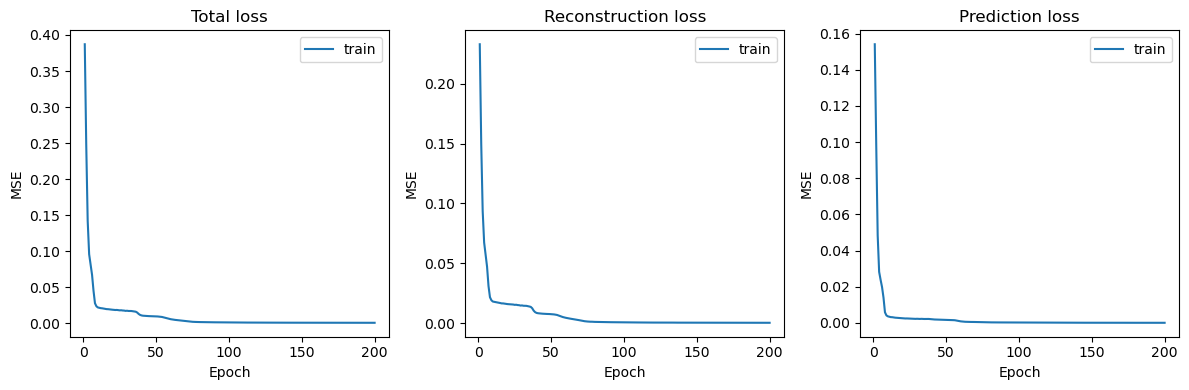

In [70]:
epochs = range(1, len(train_loss_history) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs, train_loss_history, label="train")
#plt.plot(epochs, test_loss_history, label="test")
plt.title("Total loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, train_recon_history, label="train")
#plt.plot(epochs, test_recon_history, label="test")
plt.title("Reconstruction loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs, train_pred_history, label="train")
#plt.plot(epochs, test_pred_history, label="test")
plt.title("Prediction loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()

plt.tight_layout()
plt.show()

Trajectory: traj_1004
Original shape         : (100, 24)
Reconstructed shape    : (100, 24)
Predicted future shape : (50, 24)


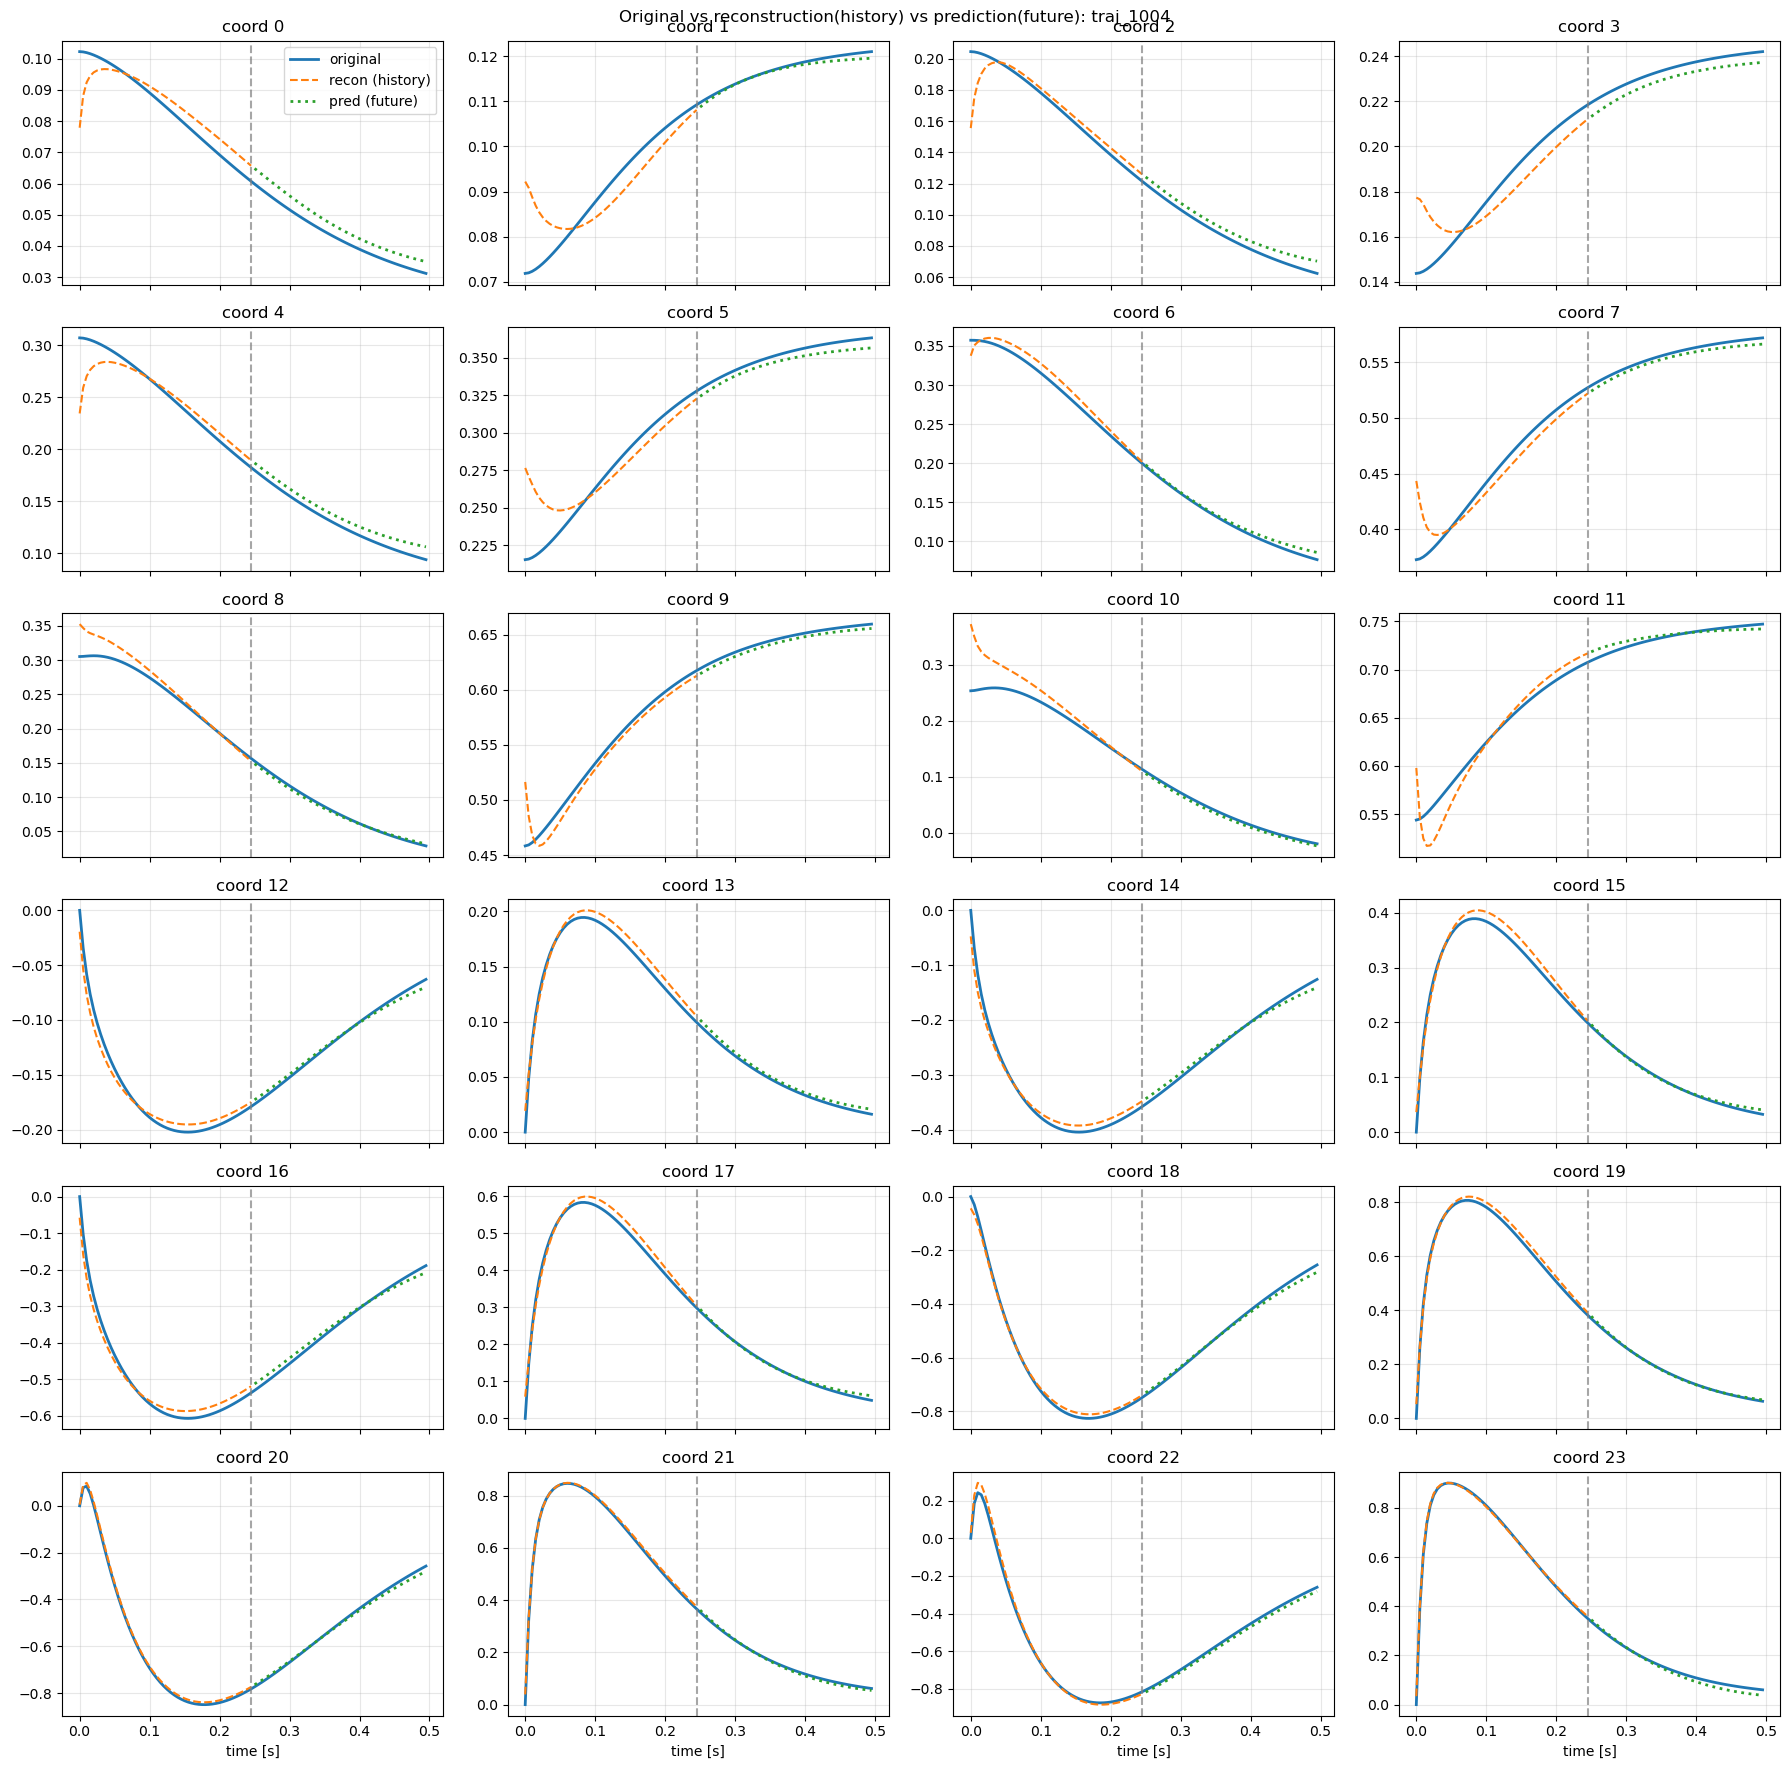

In [27]:
root = Path.cwd().resolve().parents[0]
val_dir = root / "data" / "val"

traj_dir = sorted([p for p in val_dir.iterdir() if p.is_dir()])[3]

observations_np = np.load(traj_dir / "observations.npy")   # (24, 100)
controls_np = np.load(traj_dir / "controls.npy")           # (2, 99)

dt = 0.005
time = np.arange(observations_np.shape[1]) * dt

trajectory = torch.from_numpy(observations_np.T).to(torch.float64).unsqueeze(0)
trajectory = trajectory.to(device) if "device" in globals() else trajectory
controls = torch.from_numpy(controls_np.T).to(torch.float64).unsqueeze(0)
controls = controls.to(device) if "device" in globals() else controls

m = 50

autoencoder.eval()
with torch.no_grad():
    A, B, z = compute_AB_DMD_from_trajectory(autoencoder, trajectory, controls, m)

    # reconstruction only on history
    x_recon = autoencoder.decoder(z)  # (1, T, 24)

    # prediction only on future
    z_start = z[:, m - 1, :]
    future_controls = controls[:, m - 1:, :]
    z_pred = rollout_with_AB(A, B, z_start, future_controls)
    x_pred_future = autoencoder.decoder(z_pred)  # (1, T-m, 24)

original = trajectory.squeeze(0).detach().cpu().numpy()          # (100, 24)
reconstructed = x_recon.squeeze(0).detach().cpu().numpy()        # (100, 24)
predicted_future = x_pred_future.squeeze(0).detach().cpu().numpy()  # (T-m, 24)

print("Trajectory:", traj_dir.name)
print("Original shape         :", original.shape)
print("Reconstructed shape    :", reconstructed.shape)
print("Predicted future shape :", predicted_future.shape)

fig, axes = plt.subplots(6, 4, figsize=(18, 18), sharex=True)
axes = axes.flatten()

for idx in range(24):
    ax = axes[idx]

    # original over all time
    ax.plot(time, original[:, idx], label="original", linewidth=2)

    # reconstruction only on observed/history part
    ax.plot(time[:m], reconstructed[:m, idx], "--", label="recon (history)", linewidth=1.5)

    # prediction only on future part
    ax.plot(time[m:], predicted_future[:, idx], ":", label="pred (future)", linewidth=2)

    ax.axvline(time[m - 1], color="gray", linestyle="--", alpha=0.7)
    ax.set_title(f"coord {idx}")
    ax.grid(True, alpha=0.3)

axes[0].legend(loc="best")
axes[-1].set_xlabel("time [s]")
axes[-2].set_xlabel("time [s]")
axes[-3].set_xlabel("time [s]")
axes[-4].set_xlabel("time [s]")

fig.suptitle(f"Original vs reconstruction(history) vs prediction(future): {traj_dir.name}")
fig.tight_layout()
plt.show()


In [28]:
import sys
import importlib
from pathlib import Path

repo_root = Path.cwd().resolve()

if not (repo_root / "data-generator").exists():
    repo_root = repo_root.parent

data_generator_dir = repo_root / "data-generator"

if str(data_generator_dir) not in sys.path:
    sys.path.append(str(data_generator_dir))

import params
from markers import get_marker_observation

params = importlib.reload(params)
p = params.get_params()

x_ref_np = get_marker_observation( p["q_target"], p["qdot_target"], p)

x_ref = torch.from_numpy(x_ref_np).to(device=device, dtype=torch.float64).unsqueeze(0)

autoencoder.eval()
with torch.no_grad():
    z_ref_true = autoencoder.encoder(x_ref).squeeze(0).detach().cpu().numpy()

print("x_ref shape:", x_ref.shape)
print("z_ref_true shape:", z_ref_true.shape)
print("q_target:", p["q_target"])
print("qdot_target:", p["qdot_target"])

x_ref shape: torch.Size([1, 24])
z_ref_true shape: (8,)
q_target: [ 2.0943951  -1.57079633]
qdot_target: [0. 0.]


In [29]:
from scipy.linalg import solve_discrete_are

def discrete_lqr_gain(A, B, Q, R):
    P = solve_discrete_are(A, B, Q, R)
    K = np.linalg.solve(R + B.T @ P @ B, B.T @ P @ A)
    return K


def latent_lqr_rollout(A, B, z_start, z_ref, u_ref, K, steps, u_clip=None):
    z_current = z_start
    z_preds = []
    u_preds = []

    for i in range(steps):
        u = u_ref - K @ (z_current - z_ref)

        if u_clip is not None:
            u = np.clip(u, -u_clip, u_clip)

        z_current = A @ z_current + B @ u

        z_preds.append(z_current)
        u_preds.append(u)

    return np.stack(z_preds), np.stack(u_preds)


||z_start - z_ref||: 1.832011108973961


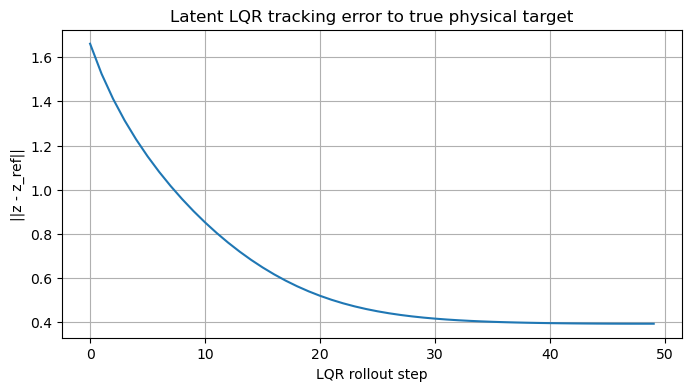

initial latent error: 1.6610566833233675
final latent error: 0.39334094859435825
relative final error: 0.23680164111400423


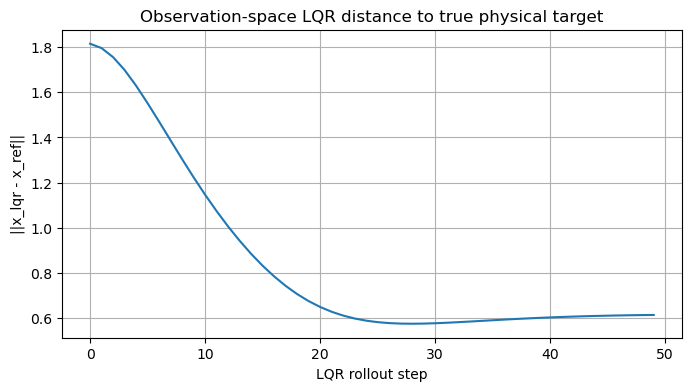

initial observation error: 1.814807884961033
final observation error: 0.6138675800503178
relative final observation error: 0.33825485614059836


In [30]:
m = 50

autoencoder.eval()
with torch.no_grad():
    A, B, z = compute_AB_DMD_from_trajectory(autoencoder, trajectory, controls, m)

A0 = A[0].detach().cpu().numpy()
B0 = B[0].detach().cpu().numpy()
z_np = z[0].detach().cpu().numpy()

z_start = z_np[m - 1]
z_ref = z_ref_true

print("||z_start - z_ref||:", np.linalg.norm(z_start - z_ref))

u_ref = np.linalg.lstsq(B0, (np.eye(A0.shape[0]) - A0) @ z_ref, rcond=None)[0]

Q = np.eye(A0.shape[0])
R = 1e-2 * np.eye(B0.shape[1])

K = discrete_lqr_gain(A0, B0, Q, R)

z_lqr, u_lqr = latent_lqr_rollout(A0, B0, z_start, z_ref, u_ref, K, steps=trajectory.shape[1] - m, u_clip=None)

z_lqr_torch = torch.from_numpy(z_lqr).to(device=device, dtype=torch.float64).unsqueeze(0)

with torch.no_grad():
    x_lqr = autoencoder.decoder(z_lqr_torch)

latent_error = np.linalg.norm(z_lqr - z_ref[None, :], axis=1)

plt.figure(figsize=(8, 4))
plt.plot(latent_error)
plt.xlabel("LQR rollout step")
plt.ylabel("||z - z_ref||")
plt.title("Latent LQR tracking error to true physical target")
plt.grid(True)
plt.show()

print("initial latent error:", latent_error[0])
print("final latent error:", latent_error[-1])
print("relative final error:", latent_error[-1] / latent_error[0])

x_lqr_np = x_lqr.squeeze(0).detach().cpu().numpy()
x_ref_np_eval = x_ref.squeeze(0).detach().cpu().numpy()
obs_error_lqr = np.linalg.norm(x_lqr_np - x_ref_np_eval[None, :], axis=1)

plt.figure(figsize=(8, 4))
plt.plot(obs_error_lqr)
plt.xlabel("LQR rollout step")
plt.ylabel("||x_lqr - x_ref||")
plt.title("Observation-space LQR distance to true physical target")
plt.grid(True)
plt.show()

print("initial observation error:", obs_error_lqr[0])
print("final observation error:", obs_error_lqr[-1])
print("relative final observation error:", obs_error_lqr[-1] / obs_error_lqr[0])